In [ ]:
import pandas as pd
import numpy as np

columns = ['engine_id','cycle','op1','op2','op3'] + [f'sensor{i}' for i in range(1,22)]

train = pd.read_csv(
    'train_FD001.txt',
    sep=' ',
    header=None
)

train = train.iloc[:,:26]

train.columns = columns

train.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388.0,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388.0,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388.0,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388.0,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388.0,100.0,38.90,23.4044


In [ ]:
print(train.shape)

train.info()

(12315, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12315 entries, 0 to 12314
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  12315 non-null  int64  
 1   cycle      12315 non-null  int64  
 2   op1        12315 non-null  float64
 3   op2        12315 non-null  float64
 4   op3        12315 non-null  float64
 5   sensor1    12315 non-null  float64
 6   sensor2    12315 non-null  float64
 7   sensor3    12315 non-null  float64
 8   sensor4    12315 non-null  float64
 9   sensor5    12315 non-null  float64
 10  sensor6    12315 non-null  float64
 11  sensor7    12315 non-null  float64
 12  sensor8    12315 non-null  float64
 13  sensor9    12315 non-null  float64
 14  sensor10   12315 non-null  float64
 15  sensor11   12315 non-null  float64
 16  sensor12   12315 non-null  float64
 17  sensor13   12315 non-null  float64
 18  sensor14   12315 non-null  float64
 19  sensor15   12315 non-null  float64

In [ ]:
max_cycle = train.groupby('engine_id')['cycle'].max()

train = train.merge(
    max_cycle.rename('max_cycle'),
    on='engine_id'
)

train['RUL'] = train['max_cycle'] - train['cycle']

train.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388.0,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388.0,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388.0,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388.0,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388.0,100.0,38.90,23.4044,192,187


In [ ]:
features = train.drop(
    ['engine_id','cycle','max_cycle','RUL'],
    axis=1
)

target = train['RUL']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    pred
)

print("MAE:", mae)

MAE: 23.88274868047097


In [ ]:
results = pd.DataFrame({
    'Actual_RUL': y_test,
    'Predicted_RUL': pred
})

results.head()

,Actual_RUL,Predicted_RUL
5640,152,109.59
8720,74,114.06
1022,93,75.88
8774,20,34.74
9992,129,129.41


In [ ]:
results.to_csv("rul_predictions.csv", index=False)

In [ ]:
import joblib

joblib.dump(model, "rul_model.pkl")

['rul_model.pkl']

In [ ]:
import os

print(os.listdir())

['.config', 'test_FD001.txt', 'rul_predictions.csv', 'train_FD004.txt', 'train_FD003.txt', 'train_FD002.txt', 'rul_model.pkl', 'train_FD001.txt', 'RUL_FD001.txt', 'sample_data']


In [ ]:
from google.colab import files

files.download("rul_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

size = os.path.getsize("rul_model.pkl")/(1024*1024)

print("Size:", size, "MB")

Size: 79.23768711090088 MB


In [1]:
import os

print(os.listdir())

['.config', 'test_FD001.txt', 'train_FD001.txt', 'RUL_FD001.txt', 'sample_data']


In [2]:
import pandas as pd

columns = [
    'engine_id','cycle','op1','op2','op3',
    'sensor1','sensor2','sensor3','sensor4','sensor5',
    'sensor6','sensor7','sensor8','sensor9','sensor10',
    'sensor11','sensor12','sensor13','sensor14','sensor15',
    'sensor16','sensor17','sensor18','sensor19','sensor20','sensor21'
]

train = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

train.columns = columns

train.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1.0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,1,2.0,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,1,3.0,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,1,4.0,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,1,5.0,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044


In [3]:
train.shape

(20632, 26)

In [4]:
rul = train.groupby('engine_id')['cycle'].max().reset_index()

rul.columns = ['engine_id', 'max_cycle']

train = train.merge(rul, on='engine_id')

train['RUL'] = train['max_cycle'] - train['cycle']

train.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1.0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190,1408.47,1407.47
1,1,2.0,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236,1408.47,1406.47
2,1,3.0,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442,1408.47,1405.47
3,1,4.0,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739,1408.47,1404.47
4,1,5.0,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044,1408.47,1403.47


In [5]:
X = train.drop(['engine_id','cycle','max_cycle','RUL'], axis=1)

y = train['RUL']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
train.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1.0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190,1408.47,1407.47
1,1,2.0,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236,1408.47,1406.47
2,1,3.0,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442,1408.47,1405.47
3,1,4.0,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739,1408.47,1404.47
4,1,5.0,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044,1408.47,1403.47


In [16]:
train.dtypes

,0
engine_id,int64
cycle,float64
op1,float64
op2,float64
op3,float64
sensor1,float64
sensor2,float64
sensor3,object
sensor4,float64
sensor5,float64


In [17]:
train.iloc[0]

,0
engine_id,1
cycle,1.0
op1,-0.0007
op2,-0.0004
op3,100.0
sensor1,518.67
sensor2,641.82
sensor3,1589.70
sensor4,1400.6
sensor5,14.62


In [18]:
train['sensor3'] = pd.to_numeric(train['sensor3'], errors='coerce')

In [19]:
train.dtypes

,0
engine_id,int64
cycle,float64
op1,float64
op2,float64
op3,float64
sensor1,float64
sensor2,float64
sensor3,float64
sensor4,float64
sensor5,float64


In [20]:
X = train.drop('RUL', axis=1)
y = train['RUL']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual_RUL': y_test,
    'Predicted_RUL': pred
})

results.head()

,Actual_RUL,Predicted_RUL
13857,79.0,79.91
1710,2.0,8.88
9278,34.0,33.00
10786,17.0,20.74
19710,74.0,71.01


In [24]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 1.7522801066149767


In [25]:
results.to_csv("rul_predictions_enhanced.csv", index=False)

print("Saved Successfully")

Saved Successfully


In [26]:
import joblib

joblib.dump(model, "rul_model_small.pkl")

['rul_model_small.pkl']

In [27]:
import os

print(
    os.path.getsize("rul_model_small.pkl")/(1024*1024),
    "MB"
)

104.13562107086182 MB


In [28]:
def maintenance_status(rul):

    if rul > 100:
        return "Healthy"

    elif rul > 30:
        return "Maintenance Soon"

    else:
        return "Critical"

results['Status'] = results['Predicted_RUL'].apply(maintenance_status)

results.head()

,Actual_RUL,Predicted_RUL,Status
13857,79.0,79.91,Maintenance Soon
1710,2.0,8.88,Critical
9278,34.0,33.00,Maintenance Soon
10786,17.0,20.74,Critical
19710,74.0,71.01,Maintenance Soon


In [29]:
results.to_csv(
    "rul_predictions_enhanced.csv",
    index=False
)

In [30]:
from google.colab import files

files.download("rul_predictions_enhanced.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
from google.colab import files

files.download("rul_model_small.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

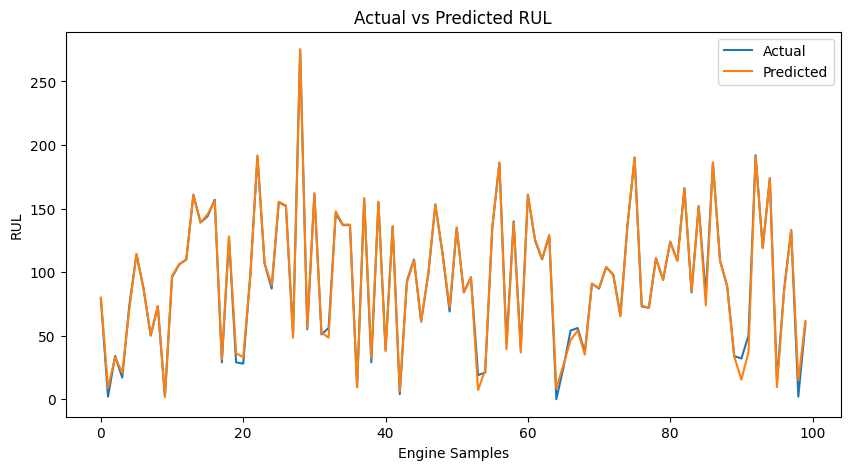

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(results['Actual_RUL'].values[:100], label='Actual')
plt.plot(results['Predicted_RUL'].values[:100], label='Predicted')

plt.xlabel("Engine Samples")
plt.ylabel("RUL")
plt.title("Actual vs Predicted RUL")
plt.legend()

plt.savefig("rul_graph.png")
plt.show()

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

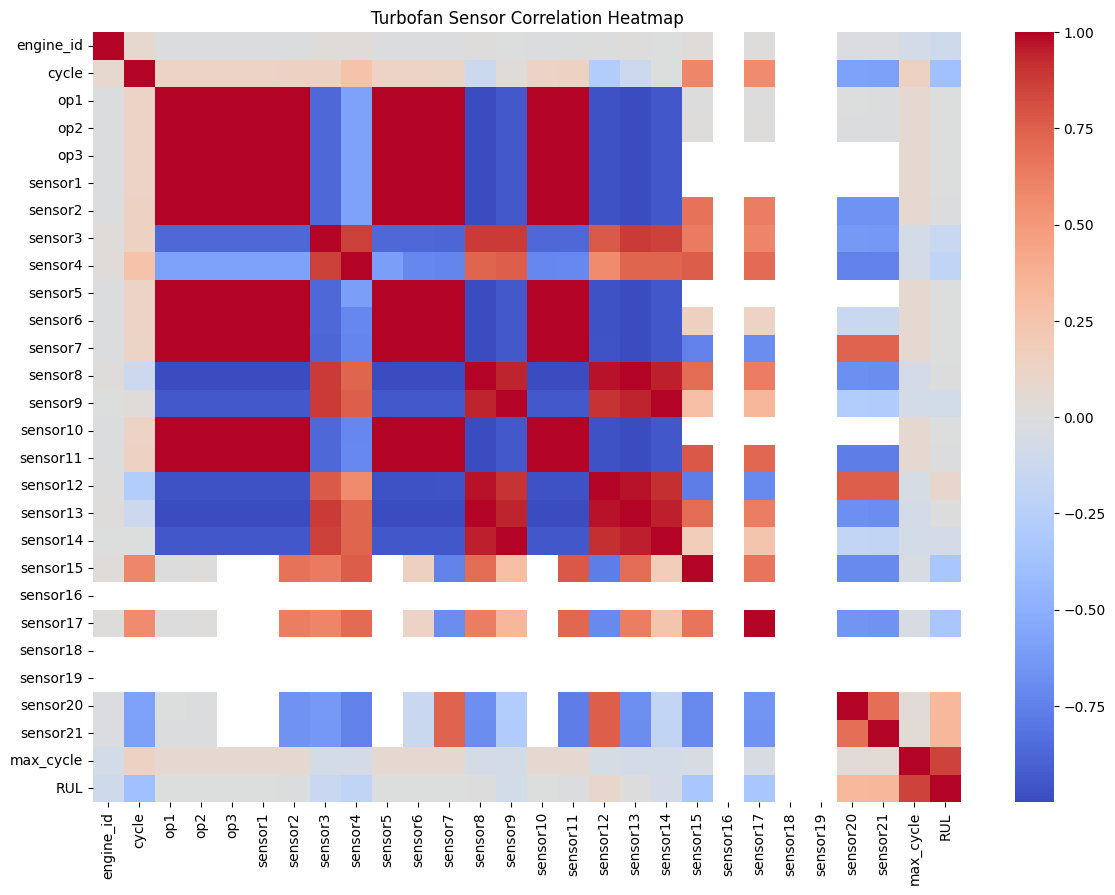

In [35]:
plt.figure(figsize=(14,10))

sns.heatmap(
    train.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Turbofan Sensor Correlation Heatmap")

plt.savefig("sensor_heatmap.png")

plt.show()

In [36]:
%whos

Variable                Type                     Data/Info
----------------------------------------------------------
RandomForestRegressor   ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X                       DataFrame                       engine_id  cycle  <...>[20632 rows x 27 columns]
X_test                  DataFrame                       engine_id  cycle  <...>n[4127 rows x 27 columns]
X_train                 DataFrame                       engine_id  cycle  <...>[16505 rows x 27 columns]
columns                 list                     n=26
files                   module                   <module 'google.colab.fil<...>s/google/colab/files.py'>
joblib                  module                   <module 'joblib' from '/u<...>ages/joblib/__init__.py'>
mae                     float                    1.7522801066149767
maintenance_status      function                 <function maintenance_status at 0x7c50c30c0540>
mean_absolute_error     function 